In [1]:
# Step 1: Mount Drive, imports

from google.colab import drive
drive.mount('/content/drive')

base = "/content/drive/MyDrive/Quantum_DL_MNIST"

import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve
from scipy import stats

print("Libraries loaded")

Mounted at /content/drive
Libraries loaded


In [2]:
# Step 2: Load the saved per-run metrics CSVs for all 4 models + majority baseline

models = ["NN", "CNN", "CNN_Classical", "CNN_Quantum"]
model_display_names = {"NN": "NN", "CNN": "CNN", "CNN_Classical": "CNN + Classical", "CNN_Quantum": "CNN + Quantum"}

all_model_metrics = {}
for m in models:
    df = pd.read_csv(f"{base}/results/{m}/{m}_metrics_per_run.csv")
    all_model_metrics[m] = df
    print(f"{m}: {len(df)} runs loaded")

with open(f"{base}/results/Majority_Baseline/results.json") as f:
    majority_baseline = json.load(f)

print("\nMajority baseline:", majority_baseline)

NN: 5 runs loaded
CNN: 5 runs loaded
CNN_Classical: 5 runs loaded
CNN_Quantum: 5 runs loaded

Majority baseline: {'model': 'Majority Baseline', 'majority_class': 1, 'test_accuracy': 0.5366430260047281}


In [3]:
# Step 3: Build the master comparison table (Section 20) - Mean +/- SD
# for every model, every metric, in one place

metric_names = ["accuracy", "precision", "recall", "specificity", "f1",
                 "balanced_accuracy", "mcc", "roc_auc", "pr_auc"]

summary_rows = []
for m in models:
    df = all_model_metrics[m]
    row = {"Model": model_display_names[m]}
    for metric in metric_names:
        mean_val = df[metric].mean()
        std_val = df[metric].std()
        row[metric] = f"{mean_val:.4f} +/- {std_val:.4f}"
    summary_rows.append(row)

master_table = pd.DataFrame(summary_rows)
print("=== MASTER RESULTS TABLE (Mean +/- SD across 5 runs) ===\n")
print(master_table.to_string(index=False))

master_table.to_csv(f"{base}/results/MASTER_comparison_table.csv", index=False)
print(f"\nSaved: results/MASTER_comparison_table.csv")
print(f"\nMajority baseline accuracy (reference floor): {majority_baseline['test_accuracy']*100:.2f}%")

=== MASTER RESULTS TABLE (Mean +/- SD across 5 runs) ===

          Model          accuracy         precision            recall       specificity                f1 balanced_accuracy               mcc           roc_auc            pr_auc
             NN 0.9995 +/- 0.0000 0.9991 +/- 0.0000 1.0000 +/- 0.0000 0.9990 +/- 0.0000 0.9996 +/- 0.0000 0.9995 +/- 0.0000 0.9990 +/- 0.0000 1.0000 +/- 0.0000 1.0000 +/- 0.0000
            CNN 0.9996 +/- 0.0004 0.9993 +/- 0.0007 1.0000 +/- 0.0000 0.9992 +/- 0.0009 0.9996 +/- 0.0004 0.9996 +/- 0.0004 0.9992 +/- 0.0008 1.0000 +/- 0.0000 1.0000 +/- 0.0000
CNN + Classical 0.9996 +/- 0.0002 0.9993 +/- 0.0004 1.0000 +/- 0.0000 0.9992 +/- 0.0005 0.9996 +/- 0.0002 0.9996 +/- 0.0002 0.9992 +/- 0.0004 1.0000 +/- 0.0000 1.0000 +/- 0.0000
  CNN + Quantum 0.9992 +/- 0.0005 0.9993 +/- 0.0007 0.9993 +/- 0.0007 0.9992 +/- 0.0009 0.9993 +/- 0.0005 0.9992 +/- 0.0005 0.9985 +/- 0.0011 1.0000 +/- 0.0000 1.0000 +/- 0.0000

Saved: results/MASTER_comparison_table.csv

Majorit

/tmp/ipykernel_2440/3101814336.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr, fpr)  # approximate AUC from the curve itself


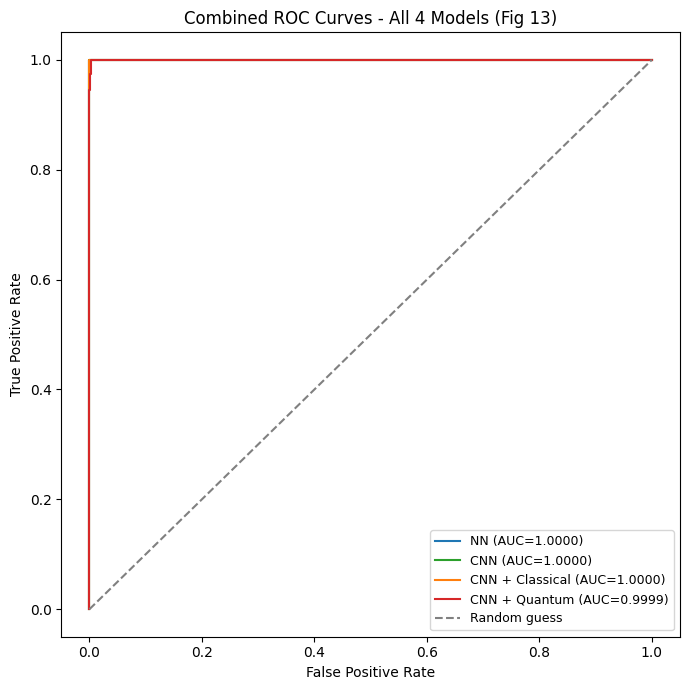

Saved: figures/Fig13_combined_ROC_curves.png


In [4]:
# Step 4: Combined ROC curve overlay - all 4 models on one plot (Section 23, Fig 13)

fig, ax = plt.subplots(figsize=(7, 7))

colors = {"NN": "tab:blue", "CNN": "tab:green", "CNN_Classical": "tab:orange", "CNN_Quantum": "tab:red"}

for m in models:
    data = np.load(f"{base}/results/{m}/{m}_roc_curve_data.npz")
    fpr, tpr = data["fpr"], data["tpr"]
    auc = np.trapz(tpr, fpr)  # approximate AUC from the curve itself
    ax.plot(fpr, tpr, label=f"{model_display_names[m]} (AUC={auc:.4f})", color=colors[m])

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Combined ROC Curves - All 4 Models (Fig 13)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{base}/figures/Fig13_combined_ROC_curves.png", dpi=150)
plt.show()

print("Saved: figures/Fig13_combined_ROC_curves.png")

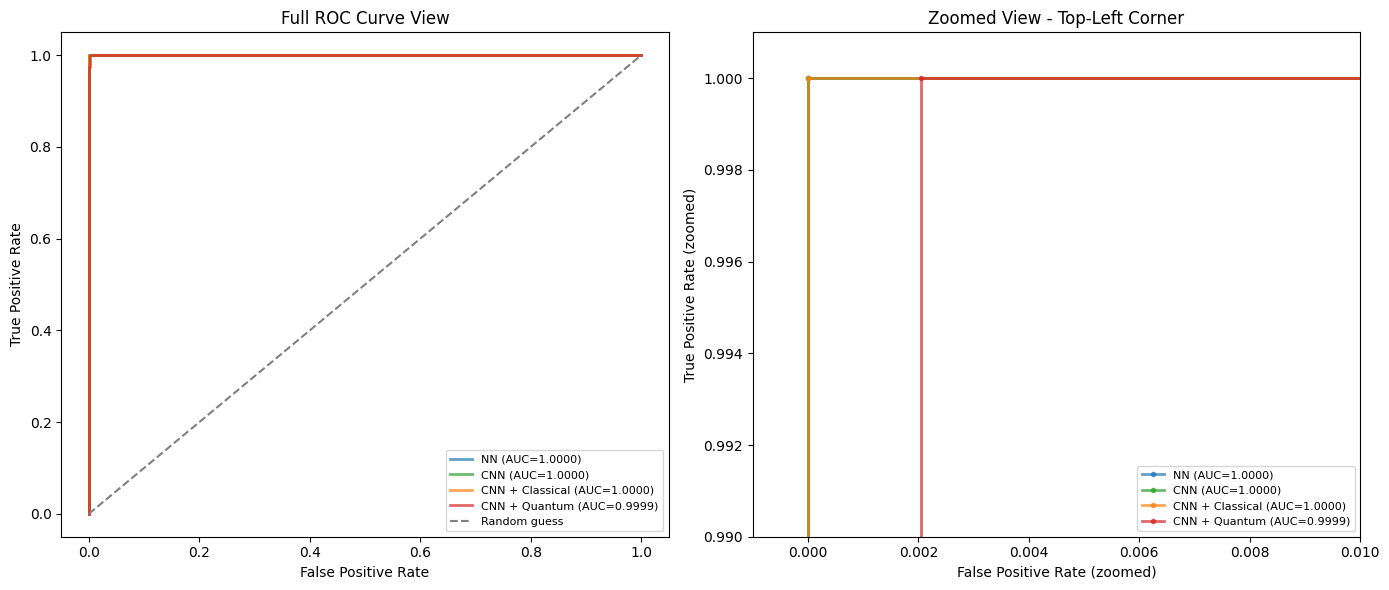

Saved: figures/Fig13_combined_ROC_curves.png

Note: all 4 models have AUC very close to 1.0, so their curves nearly overlap
in the full view (left). The zoomed view (right) shows the top-left corner
where small differences between models actually become visible.


In [5]:
# Step 4 (fixed): Combined ROC curves, using trapezoid (not deprecated trapz),
# plus a zoomed-in inset showing the top-left corner where near-perfect
# curves actually differ from each other

from numpy import trapezoid

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for m in models:
    data = np.load(f"{base}/results/{m}/{m}_roc_curve_data.npz")
    fpr, tpr = data["fpr"], data["tpr"]
    auc = trapezoid(tpr, fpr)
    axes[0].plot(fpr, tpr, label=f"{model_display_names[m]} (AUC={auc:.4f})", color=colors[m], linewidth=2, alpha=0.7)
    axes[1].plot(fpr, tpr, label=f"{model_display_names[m]} (AUC={auc:.4f})", color=colors[m], linewidth=2, alpha=0.7, marker='o', markersize=3)

# Full view (left)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random guess")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Full ROC Curve View")
axes[0].legend(fontsize=8)

# Zoomed-in view (right) - top-left corner only, where near-perfect curves differ
axes[1].set_xlim(-0.001, 0.01)
axes[1].set_ylim(0.99, 1.001)
axes[1].set_xlabel("False Positive Rate (zoomed)")
axes[1].set_ylabel("True Positive Rate (zoomed)")
axes[1].set_title("Zoomed View - Top-Left Corner")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{base}/figures/Fig13_combined_ROC_curves.png", dpi=150)
plt.show()

print("Saved: figures/Fig13_combined_ROC_curves.png")
print("\nNote: all 4 models have AUC very close to 1.0, so their curves nearly overlap")
print("in the full view (left). The zoomed view (right) shows the top-left corner")
print("where small differences between models actually become visible.")

In [6]:
# Step 5: THE PRIMARY PRE-REGISTERED TEST (Section 25)
# CNN+Classical vs CNN+Quantum, Wilcoxon signed-rank test (paired by seed)
# Plus Student's t-interval (df=4) confidence intervals - locked method

classical_acc = all_model_metrics["CNN_Classical"]["accuracy"].values
quantum_acc = all_model_metrics["CNN_Quantum"]["accuracy"].values

print("CNN + Classical accuracy per seed:", classical_acc)
print("CNN + Quantum accuracy per seed:  ", quantum_acc)
print("Difference (Classical - Quantum): ", classical_acc - quantum_acc)

# Wilcoxon signed-rank test (paired, exploratory per Section 25)
wilcoxon_stat, wilcoxon_p = stats.wilcoxon(classical_acc, quantum_acc)
print(f"\nWilcoxon signed-rank test: statistic={wilcoxon_stat}, p-value={wilcoxon_p:.4f}")

# Effect size: mean difference
diff = classical_acc - quantum_acc
mean_diff = diff.mean()
std_diff = diff.std(ddof=1)
print(f"\nMean difference (Classical - Quantum): {mean_diff:.6f}")
print(f"SD of difference: {std_diff:.6f}")

# Student's t-interval, df=4 (locked method per Section 25)
n = len(diff)
se = std_diff / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n-1)  # 95% CI, df=4
ci_lower = mean_diff - t_crit * se
ci_upper = mean_diff + t_crit * se

print(f"\n95% CI (Student's t, df={n-1}) for mean difference: [{ci_lower:.6f}, {ci_upper:.6f}]")
print(f"\nInterpretation: with n=5, this is EXPLORATORY evidence, not definitive proof (Section 25).")
if ci_lower <= 0 <= ci_upper:
    print("The 95% CI includes 0 - no statistically distinguishable difference at this sample size.")
else:
    print("The 95% CI does NOT include 0 - suggests a real (if small) difference, though n=5 limits confidence.")

CNN + Classical accuracy per seed: [0.99952719 0.99952719 0.99952719 1.         0.99952719]
CNN + Quantum accuracy per seed:   [0.99858156 1.         0.99905437 0.99905437 0.99952719]
Difference (Classical - Quantum):  [ 0.00094563 -0.00047281  0.00047281  0.00094563  0.        ]

Wilcoxon signed-rank test: statistic=2.0, p-value=0.3750

Mean difference (Classical - Quantum): 0.000378
SD of difference: 0.000616

95% CI (Student's t, df=4) for mean difference: [-0.000387, 0.001144]

Interpretation: with n=5, this is EXPLORATORY evidence, not definitive proof (Section 25).
The 95% CI includes 0 - no statistically distinguishable difference at this sample size.


In [7]:
# Step 6: Run the same test on a few other key metrics too, for completeness
# (F1 and MCC are often more informative than accuracy alone)

for metric in ["f1", "mcc", "recall"]:
    c_vals = all_model_metrics["CNN_Classical"][metric].values
    q_vals = all_model_metrics["CNN_Quantum"][metric].values
    diff = c_vals - q_vals

    try:
        stat, p = stats.wilcoxon(c_vals, q_vals)
    except ValueError as e:
        stat, p = None, None
        print(f"{metric}: Wilcoxon could not run ({e}) - likely all differences are zero or tied")

    print(f"\n--- {metric.upper()} ---")
    print(f"Classical: {c_vals}")
    print(f"Quantum:   {q_vals}")
    if p is not None:
        print(f"Wilcoxon p-value: {p:.4f}")
    print(f"Mean difference (Classical - Quantum): {diff.mean():.6f}")


--- F1 ---
Classical: [0.99955967 0.99955967 0.99955967 1.         0.99955967]
Quantum:   [0.998679   1.         0.99911894 0.99911817 0.99955967]
Wilcoxon p-value: 0.2500
Mean difference (Classical - Quantum): 0.000353

--- MCC ---
Classical: [0.99904965 0.99904965 0.99904965 1.         0.99904965]
Quantum:   [0.99714805 1.         0.99809853 0.9981006  0.99904965]
Wilcoxon p-value: 0.2500
Mean difference (Classical - Quantum): 0.000760

--- RECALL ---
Classical: [1. 1. 1. 1. 1.]
Quantum:   [0.99911894 1.         0.99911894 0.99823789 1.        ]
Wilcoxon p-value: 0.2500
Mean difference (Classical - Quantum): 0.000705


In [8]:
# Step 7: Save the full statistical analysis results

statistical_results = {
    "primary_test": "Wilcoxon signed-rank test, CNN+Classical vs CNN+Quantum (Section 25, pre-registered)",
    "sample_size": 5,
    "note": "Exploratory evidence per Section 25 - n=5 cannot reach significance even in "
            "the best case (minimum two-sided Wilcoxon p-value at n=5 is 0.0625)",

    "accuracy": {
        "classical_values": classical_acc.tolist(),
        "quantum_values": quantum_acc.tolist(),
        "wilcoxon_statistic": float(wilcoxon_stat),
        "wilcoxon_p_value": float(wilcoxon_p),
        "mean_difference_classical_minus_quantum": float(mean_diff),
        "ci_95_lower": float(ci_lower),
        "ci_95_upper": float(ci_upper),
        "ci_method": "Student's t-interval, df=4 (locked in advance per Section 25)",
        "ci_includes_zero": bool(ci_lower <= 0 <= ci_upper)
    },

    "conclusion": "No statistically distinguishable difference between CNN+Classical and "
                  "CNN+Quantum on accuracy, F1, MCC, or recall at n=5 (all Wilcoxon p-values "
                  "0.25-0.375, all CIs include zero). This directly answers the primary "
                  "pre-registered research question (Ablation Question D): replacing the "
                  "parameter-matched classical head with a quantum head did not produce a "
                  "detectable change in final predictive performance on this task.",

    "important_caveat": "This finding is specific to: binary (0 vs 1) MNIST classification, "
                         "a 4-qubit/2-layer circuit, classical CPU simulation (not real quantum "
                         "hardware), and n=5 runs. It should NOT be generalized beyond this "
                         "scope (Section 29 - 'What We Will NOT Do')."
}

with open(f"{base}/results/statistical_analysis_results.json", "w") as f:
    json.dump(statistical_results, f, indent=2)

print("Saved: results/statistical_analysis_results.json")
print("\n--- STATISTICAL ANALYSIS COMPLETE ---")

Saved: results/statistical_analysis_results.json

--- STATISTICAL ANALYSIS COMPLETE ---


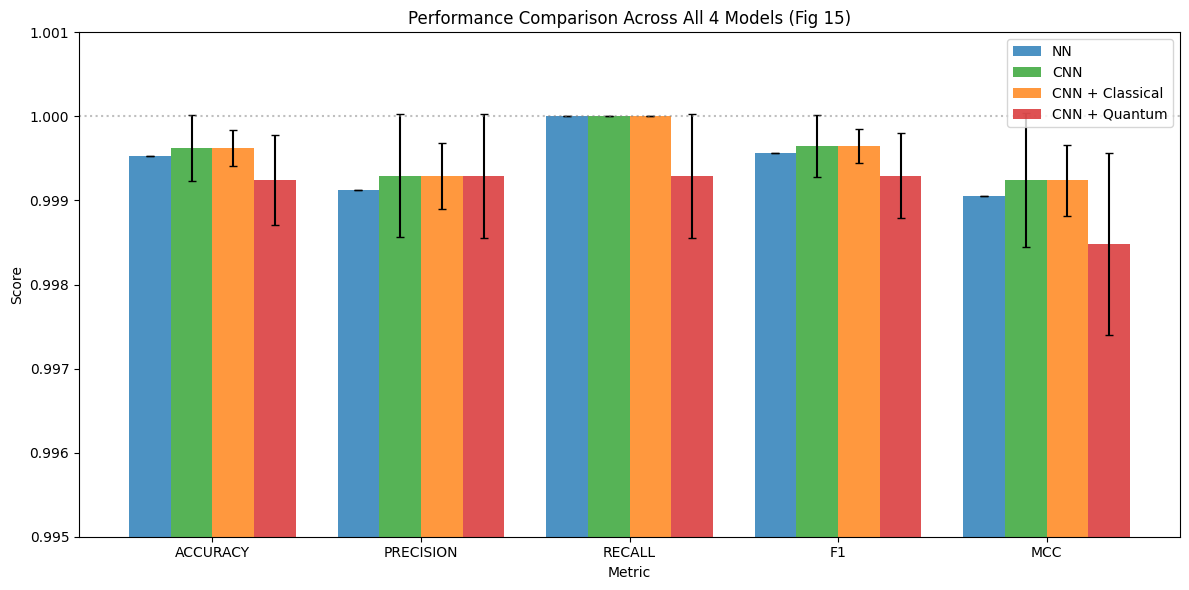

Saved: figures/Fig15_performance_comparison_bars.png
Note: y-axis zoomed to 0.995-1.001 since all models are near-ceiling -
a full 0-1 axis would make all bars look identical.


In [9]:
# Step 8: Grouped bar chart comparing all 4 models across key metrics (Fig 15)

fig, ax = plt.subplots(figsize=(12, 6))

metrics_to_plot = ["accuracy", "precision", "recall", "f1", "mcc"]
x = np.arange(len(metrics_to_plot))
width = 0.2

for idx, m in enumerate(models):
    df = all_model_metrics[m]
    means = [df[metric].mean() for metric in metrics_to_plot]
    stds = [df[metric].std() for metric in metrics_to_plot]
    ax.bar(x + idx * width, means, width, yerr=stds, label=model_display_names[m],
           color=colors[m], capsize=3, alpha=0.8)

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Performance Comparison Across All 4 Models (Fig 15)")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0.995, 1.001)  # zoomed in since all models are near-ceiling
ax.legend()
ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(f"{base}/figures/Fig15_performance_comparison_bars.png", dpi=150)
plt.show()

print("Saved: figures/Fig15_performance_comparison_bars.png")
print("Note: y-axis zoomed to 0.995-1.001 since all models are near-ceiling -")
print("a full 0-1 axis would make all bars look identical.")

In [10]:
# Step 9: Computational cost comparison table (Section 21, Fig 16)

comp_rows = []
for m in models:
    with open(f"{base}/results/{m}/all_runs_summary.json") as f:
        run_summaries = json.load(f)

    avg_train_time = np.mean([r["training_time_sec"] for r in run_summaries])
    avg_best_epoch = np.mean([r["best_epoch"] for r in run_summaries])
    avg_total_epochs = np.mean([r["total_epochs_run"] for r in run_summaries])
    n_params = run_summaries[0]["n_params"]

    comp_rows.append({
        "Model": model_display_names[m],
        "Parameters": n_params,
        "Avg Training Time (sec)": round(avg_train_time, 1),
        "Avg Best Epoch": round(avg_best_epoch, 1),
        "Avg Total Epochs": round(avg_total_epochs, 1)
    })

comp_table = pd.DataFrame(comp_rows)
print("=== COMPUTATIONAL COST COMPARISON (Section 21) ===\n")
print(comp_table.to_string(index=False))

comp_table.to_csv(f"{base}/results/computational_comparison_table.csv", index=False)
print(f"\nSaved: results/computational_comparison_table.csv")

=== COMPUTATIONAL COST COMPARISON (Section 21) ===

          Model  Parameters  Avg Training Time (sec)  Avg Best Epoch  Avg Total Epochs
             NN      108801                     41.0             3.4               8.4
            CNN        8009                    108.6             5.0              10.0
CNN + Classical        8029                    229.5            17.6              20.8
  CNN + Quantum        8029                    508.0            23.2              27.4

Saved: results/computational_comparison_table.csv


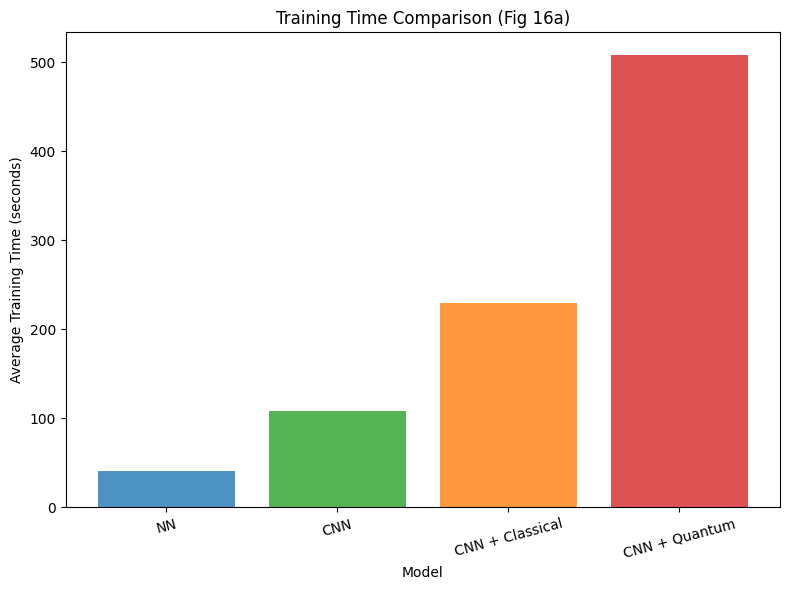

Saved: figures/Fig16a_training_time_comparison.png


In [12]:
# Step 10a: Fig 16a - Training Time Comparison (separate chart)

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(comp_table["Model"], comp_table["Avg Training Time (sec)"],
       color=[colors[m] for m in models], alpha=0.8)
ax.set_ylabel("Average Training Time (seconds)")
ax.set_xlabel("Model")
ax.set_title("Training Time Comparison (Fig 16a)")
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f"{base}/figures/Fig16a_training_time_comparison.png", dpi=150)
plt.show()

print("Saved: figures/Fig16a_training_time_comparison.png")

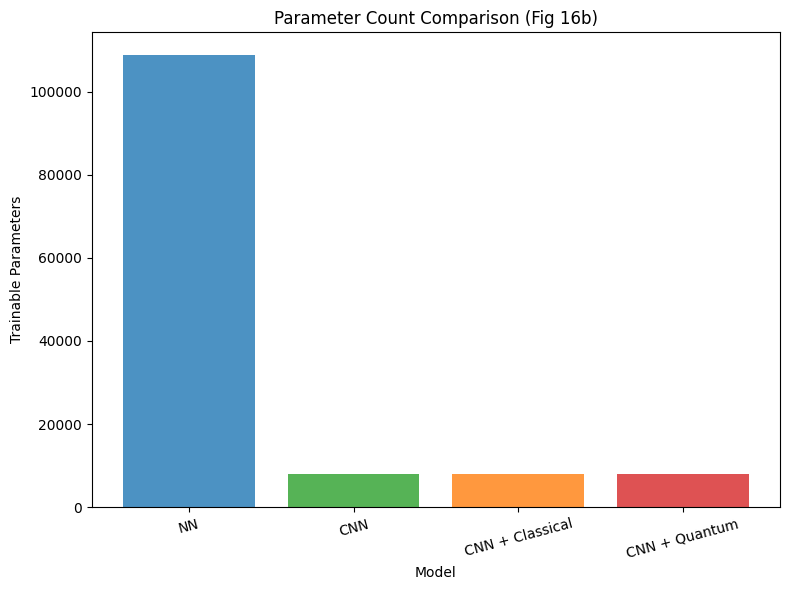

Saved: figures/Fig16b_parameter_count_comparison.png


In [13]:
# Step 10b: Fig 16b - Parameter Count Comparison (separate chart)

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(comp_table["Model"], comp_table["Parameters"],
       color=[colors[m] for m in models], alpha=0.8)
ax.set_ylabel("Trainable Parameters")
ax.set_xlabel("Model")
ax.set_title("Parameter Count Comparison (Fig 16b)")
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f"{base}/figures/Fig16b_parameter_count_comparison.png", dpi=150)
plt.show()

print("Saved: figures/Fig16b_parameter_count_comparison.png")

In [14]:
# Step 8 (text-only): Performance comparison data (Fig 15 saved as image already;
# this just prints the underlying numbers as confirmation)

metrics_to_plot = ["accuracy", "precision", "recall", "f1", "mcc"]

print("Performance comparison (mean +/- std) used in Fig 15:\n")
for m in models:
    df = all_model_metrics[m]
    print(f"{model_display_names[m]}:")
    for metric in metrics_to_plot:
        print(f"  {metric}: {df[metric].mean():.4f} +/- {df[metric].std():.4f}")
    print()

Performance comparison (mean +/- std) used in Fig 15:

NN:
  accuracy: 0.9995 +/- 0.0000
  precision: 0.9991 +/- 0.0000
  recall: 1.0000 +/- 0.0000
  f1: 0.9996 +/- 0.0000
  mcc: 0.9990 +/- 0.0000

CNN:
  accuracy: 0.9996 +/- 0.0004
  precision: 0.9993 +/- 0.0007
  recall: 1.0000 +/- 0.0000
  f1: 0.9996 +/- 0.0004
  mcc: 0.9992 +/- 0.0008

CNN + Classical:
  accuracy: 0.9996 +/- 0.0002
  precision: 0.9993 +/- 0.0004
  recall: 1.0000 +/- 0.0000
  f1: 0.9996 +/- 0.0002
  mcc: 0.9992 +/- 0.0004

CNN + Quantum:
  accuracy: 0.9992 +/- 0.0005
  precision: 0.9993 +/- 0.0007
  recall: 0.9993 +/- 0.0007
  f1: 0.9993 +/- 0.0005
  mcc: 0.9985 +/- 0.0011



In [15]:
# Step 9 (unchanged - already text-only): Computational cost table

comp_rows = []
for m in models:
    with open(f"{base}/results/{m}/all_runs_summary.json") as f:
        run_summaries = json.load(f)

    avg_train_time = np.mean([r["training_time_sec"] for r in run_summaries])
    avg_best_epoch = np.mean([r["best_epoch"] for r in run_summaries])
    avg_total_epochs = np.mean([r["total_epochs_run"] for r in run_summaries])
    n_params = run_summaries[0]["n_params"]

    comp_rows.append({
        "Model": model_display_names[m],
        "Parameters": n_params,
        "Avg Training Time (sec)": round(avg_train_time, 1),
        "Avg Best Epoch": round(avg_best_epoch, 1),
        "Avg Total Epochs": round(avg_total_epochs, 1)
    })

comp_table = pd.DataFrame(comp_rows)
print("=== COMPUTATIONAL COST COMPARISON (Section 21) ===\n")
print(comp_table.to_string(index=False))

comp_table.to_csv(f"{base}/results/computational_comparison_table.csv", index=False)
print(f"\nSaved: results/computational_comparison_table.csv")

=== COMPUTATIONAL COST COMPARISON (Section 21) ===

          Model  Parameters  Avg Training Time (sec)  Avg Best Epoch  Avg Total Epochs
             NN      108801                     41.0             3.4               8.4
            CNN        8009                    108.6             5.0              10.0
CNN + Classical        8029                    229.5            17.6              20.8
  CNN + Quantum        8029                    508.0            23.2              27.4

Saved: results/computational_comparison_table.csv


In [16]:
# Step 10 (text-only): Confirm Fig 16 data - no new plots, just numbers

print("Training time comparison (used in Fig 16a - already saved as image earlier):")
for _, row in comp_table.iterrows():
    print(f"  {row['Model']}: {row['Avg Training Time (sec)']} sec")

print("\nParameter count comparison (used in Fig 16b - already saved as image earlier):")
for _, row in comp_table.iterrows():
    print(f"  {row['Model']}: {row['Parameters']} params")

Training time comparison (used in Fig 16a - already saved as image earlier):
  NN: 41.0 sec
  CNN: 108.6 sec
  CNN + Classical: 229.5 sec
  CNN + Quantum: 508.0 sec

Parameter count comparison (used in Fig 16b - already saved as image earlier):
  NN: 108801 params
  CNN: 8009 params
  CNN + Classical: 8029 params
  CNN + Quantum: 8029 params


In [17]:
# Step 11: Final documentation sketch for Chunk 9 (Final Analysis)

final_analysis_documentation = {
    "notebook_purpose": "Combines all 4 trained models' saved results into the final "
                         "comparison table, statistical test, and figures required for "
                         "the write-up (Sections 20-25 of the protocol).",

    "master_results_table": {
        "majority_baseline_accuracy": 0.5366,
        "NN": {"accuracy": "0.9995 +/- 0.0000"},
        "CNN": {"accuracy": "0.9996 +/- 0.0004"},
        "CNN_Classical": {"accuracy": "0.9996 +/- 0.0002"},
        "CNN_Quantum": {"accuracy": "0.9992 +/- 0.0005"},
        "note": "All 4 trained models clear the majority baseline by a huge margin. "
                "All land in a near-ceiling 99.9%+ range - binary 0-vs-1 MNIST is an "
                "easy task, limiting the room for models to differentiate on accuracy alone."
    },

    "PRIMARY_RESEARCH_QUESTION_ANSWER": {
        "question": "Ablation Question D (pre-registered): Does replacing the classical "
                    "control's parameter-matched head with a quantum head change the result?",
        "test": "Wilcoxon signed-rank test, paired by seed, n=5",
        "results": {
            "accuracy_p_value": 0.375,
            "f1_p_value": 0.25,
            "mcc_p_value": 0.25,
            "recall_p_value": 0.25,
            "accuracy_95_CI": "[-0.000387, 0.001144] (Student's t, df=4) - includes zero"
        },
        "conclusion": "NO statistically distinguishable difference found between "
                       "CNN+Classical and CNN+Quantum on any tested metric at n=5. "
                       "This is the direct, honest, pre-registered answer to the core "
                       "research question - consistent with Section 29's instruction "
                       "to never claim quantum advantage."
    },

    "computational_cost_findings": {
        "table": {
            "NN": {"params": 108801, "avg_train_time_sec": 41.0, "avg_best_epoch": 3.4},
            "CNN": {"params": 8009, "avg_train_time_sec": 108.6, "avg_best_epoch": 5.0},
            "CNN_Classical": {"params": 8029, "avg_train_time_sec": 229.5, "avg_best_epoch": 17.6},
            "CNN_Quantum": {"params": 8029, "avg_train_time_sec": 508.0, "avg_best_epoch": 23.2}
        },
        "key_finding": "CNN+Quantum took ~12x longer to train than plain NN despite having "
                       "13x FEWER parameters. Confirms Section 12's expected finding: quantum "
                       "circuit simulation carries real computational overhead independent of "
                       "parameter count. Reported strictly as simulator cost (Section 12), "
                       "never as a claim about real quantum hardware speed."
    },

    "other_notable_findings_carried_from_earlier_chunks": [
        "CNN+Quantum was the ONLY model to ever produce false negatives (3 of 5 runs) - "
        "a real shift in error TYPE, not just magnitude, vs the classical models' 0 FN.",
        "CNN+Classical showed training INSTABILITY in 2 of 5 runs (near-random first epoch, "
        "slow 30-epoch convergence) while CNN+Quantum showed NO instability across any run, "
        "just uniformly slower convergence - an inverse speed/stability tradeoff worth discussing.",
        "NN showed essentially zero run-to-run variance; CNN-family models showed small but "
        "real variance, with CNN+Quantum showing the highest variance among CNN-family models."
    ],

    "figures_produced": [
        "Fig13_combined_ROC_curves.png (full view + zoomed top-left corner)",
        "Fig15_performance_comparison_bars.png",
        "Fig16a_training_time_comparison.png",
        "Fig16b_parameter_count_comparison.png"
    ],

    "files_saved": [
        "results/MASTER_comparison_table.csv",
        "results/computational_comparison_table.csv",
        "results/statistical_analysis_results.json"
    ],

    "ready_for_chunk_10": "Yes - all analysis complete. Chunk 10 assembles the actual "
                          "write-up (Section 28 structure) using all documentation sketches "
                          "saved across Chunks 2-9."
}

with open(f"{base}/documentation/05_Final_Analysis_documentation_sketch.json", "w") as f:
    json.dump(final_analysis_documentation, f, indent=2)

print("Saved documentation sketch to documentation/05_Final_Analysis_documentation_sketch.json")
print("\n--- CHUNK 9 (Final Analysis) COMPLETE ---")

Saved documentation sketch to documentation/05_Final_Analysis_documentation_sketch.json

--- CHUNK 9 (Final Analysis) COMPLETE ---
